## Session 2: Specialist vs Generalist Agents

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [5]:
load_dotenv()

model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

## Part 1: Generalist Agent

One node. One prompt. It tries to answer every kind of query by itself.

In [6]:
class GeneralistState(TypedDict):

    query: str
    answer: str

In [7]:
def generalist(state: GeneralistState):

    query = state['query']

    prompt = f'You are a helpful support assistant. Answer this user query:\n{query}'
    answer = model.invoke(prompt).content

    return {'answer': answer}

In [8]:
graph = StateGraph(GeneralistState)

# nodes
graph.add_node('generalist', generalist)

# edges
graph.add_edge(START, 'generalist')
graph.add_edge('generalist', END)

generalist_workflow = graph.compile()

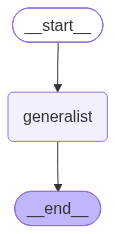

In [9]:
generalist_workflow

In [10]:
queries = [
    'Why was I charged twice on my last invoice?',
    'The app crashes every time I upload a photo',
    'What are your support hours?'
]

for query in queries:
    result = generalist_workflow.invoke({'query': query})
    print('QUERY:', query)
    print('ANSWER:', result['answer'])
    print('-' * 60)

QUERY: Why was I charged twice on my last invoice?
ANSWER: I’m sorry about that. A double charge on an invoice can happen for a few reasons, such as:

- A duplicate payment was accidentally processed
- Your bank shows a temporary authorization hold that looks like a second charge
- The invoice was issued twice due to a billing system error
- A previous failed payment was retried and then succeeded

If you’d like, I can help you check which of these applies. Please share:
- The invoice number
- The date(s) of the charge(s)
- The last 4 digits of the card or payment method used

If you’re seeing two **completed** charges, we should be able to review and correct it.
------------------------------------------------------------
QUERY: The app crashes every time I upload a photo
ANSWER: Sorry about that — I can help troubleshoot.

Please try these quick steps:
1. **Close and reopen the app**
2. **Restart your phone**
3. **Check for app updates** in the App Store / Google Play
4. **Make sure 

## Part 2: Specialist Agents

A router first decides the category. Then the query goes to the matching specialist.

In [11]:
class RouteSchema(BaseModel):

    category: Literal["billing", "technical", "general"] = Field(description='Which specialist should handle this query')

In [12]:
structured_model = model.with_structured_output(RouteSchema)

In [13]:
class SpecialistState(TypedDict):

    query: str
    category: Literal["billing", "technical", "general"]
    answer: str

In [15]:
def classify_query(state: SpecialistState):

    prompt = f'''Classify this support query into one category: billing, technical, or general.

billing = payments, invoices, refunds, charges
technical = bugs, crashes, login, app not working
general = hours, policies, anything else

Query: {state["query"]}'''

    category = structured_model.invoke(prompt).category

    return {'category': category}


def route_query(state: SpecialistState) -> Literal["billing_specialist", "technical_specialist", "general_specialist"]:

    if state['category'] == 'billing':
        return 'billing_specialist'
    elif state['category'] == 'technical':
        return 'technical_specialist'
    else:
        return 'general_specialist'


def billing_specialist(state: SpecialistState):

    prompt = f'''You are a billing specialist.
Help with invoices, refunds, and charges.
Always mention that this reply is from the Billing Team.

Query: {state["query"]}'''

    answer = model.invoke(prompt).content

    return {'answer': answer}


def technical_specialist(state: SpecialistState):

    prompt = f'''You are a technical support specialist.
Help with bugs, crashes, and app issues.
Always mention that this reply is from Tech Support.
Give short practical steps.

Query: {state["query"]}'''

    answer = model.invoke(prompt).content

    return {'answer': answer}


def general_specialist(state: SpecialistState):

    prompt = f'''You are a general helpdesk specialist.
Help with hours, policies, and basic questions.
Always mention that this reply is from the Helpdesk.

Query: {state["query"]}'''

    answer = model.invoke(prompt).content

    return {'answer': answer}

In [16]:
graph = StateGraph(SpecialistState)

# nodes
graph.add_node('classify_query', classify_query)
graph.add_node('billing_specialist', billing_specialist)
graph.add_node('technical_specialist', technical_specialist)
graph.add_node('general_specialist', general_specialist)

# edges
graph.add_edge(START, 'classify_query')
graph.add_conditional_edges('classify_query', route_query)
graph.add_edge('billing_specialist', END)
graph.add_edge('technical_specialist', END)
graph.add_edge('general_specialist', END)

specialist_workflow = graph.compile()

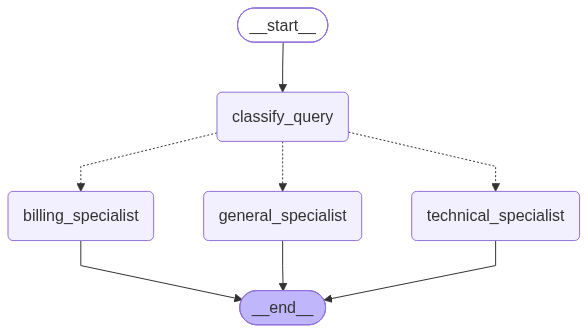

In [17]:
specialist_workflow

In [18]:
for query in queries:
    result = specialist_workflow.invoke({'query': query})
    print('QUERY:', query)
    print('CATEGORY:', result['category'])
    print('ANSWER:', result['answer'])
    print('-' * 60)

QUERY: Why was I charged twice on my last invoice?
CATEGORY: billing
ANSWER: This reply is from the Billing Team.

There are a few common reasons you might see what looks like a double charge on the last invoice:

1. **Two separate line items** were billed on the same date.
2. **A failed payment retry** may have created a second authorization or pending charge.
3. **Proration or adjustments** from a plan change can appear as an extra charge.
4. **Invoice duplication** due to a system or payment processing issue.

To confirm the exact reason, please check:
- the **invoice number(s)**,
- the **charge dates**,
- and whether both charges are **posted** or one is only **pending/authorized**.

If you’d like, send me:
- the invoice number,
- the last 4 digits of the card used,
- and a screenshot or the exact amounts,

and I can help determine whether it was a duplicate charge, an authorization hold, or a legitimate second charge.
------------------------------------------------------------
QU